# Breast Cancer Classification from Fine Needle Aspiration Measurements

Comparing a regularised logistic regression baseline against a small feedforward neural network on the Wisconsin Diagnostic Breast Cancer dataset, with attention to the sensitivity/specificity trade-off that matters in a screening context.


**The question**

*Can morphological features of breast cell nuclei extracted from Fine Needle Aspiration (FNA) biopsies accurately predict whether a breast tumour is malignant or benign, so that clinicians can make faster, more objective, and more consistent triage decisions during their initial diagnostic assessment?*

This is a predictive research question as the aim is to classify a clinical outcome based on a set of continuous input features. While we do not know the exact time point at which each FNA was taken (t₀), this does not affect the task as our goal is static classification using fixed features collected at the moment the FNA biopsy was performed rather than a time-dependent prediction.

Benign tumours are non-cancerous growths that remain localized, do not invade surrounding tissue, and are not life-threatening. Malignant tumours, by contrast, are cancerous and capable of spreading to other parts of the body, causing significant harm through metastasis and damage to vital organs (National Cancer Institute, n.d.). Early and accurate detection is critical as treatment is most effective during the initial stages of the disease. A false negative (malignant tumour classified as benign) is quite dangerous as the patient might not receive any treatment, resulting in the cancer progressing undetected and increasing the risk of mortality. A false positive (benign tumour classified as malignant) also causes harm, although to a lesser extent, as the patient is subjected to unnecessary procedures, distress, and financial costs while their original symptoms remain misdiagnosed.

Tumour classification therefore directly determines the care pathway a patient receives and is an integral first step in treatment. FNA tests are faster, less invasive, and more cost-effective than full biopsies or imaging-based assessments, and therefore have considerable practical benefit. However, diagnosis by manual inspection of FNA samples is highly subjective and dependent on physician skill and experience.

Automated classification using machine learning has the potential to improve the objectivity and consistency of FNA diagnoses, thereby improving patient outcomes (Street, Wolberg, and Mangasarian, 1993). While these models may not fully replace the clinician, improving their diagnostic reliability as a preliminary screening tool would be of significant clinical value. A well-performing classification model could support triage by filtering out cases that are highly likely to be benign, reducing unnecessary follow-up procedures and allowing clinicians to focus their attention on truly ambiguous or high-risk cases. It could also serve as a decision support aid, providing an objective probability estimate that a clinician can reference alongside their own assessment. This way, the model can improve the consistency and confidence of diagnostic decisions, especially in settings where human expertise is limited.

Hence, this health question can be framed as a supervised binary classification task. Given labelled FNA measurements from the Wisconsin Breast Cancer Dataset, the goal is to train a model to distinguish between malignant and benign tumours based on morphological features extracted from cell nuclei and to generalize this to new, unseen cases.

**What counts as success**

Success in this clinical context cannot be reduced to a single metric as the objective of the model directly determines the choice of evaluation metric and what it is being optimized for in practice. Considering that the malignant class is the diagnosis that influences the most consequential clinical decisions, evaluation should be framed with respect to the model's performance for this class in particular.

Accuracy measures the overall proportion of correct predictions and provides a useful baseline for comparing models. It is most informative when classes are balanced and the cost of each type of error is equal. However, it is insufficient and potentially misleading as a standalone measure of clinical success when classes are imbalanced. In this dataset, benign cases outnumber malignant cases (357 vs. 212), which means that a model that naively predicts every case as benign would still achieve 63% accuracy even though it failed to detect a single malignant tumour. A model achieving high accuracy could therefore still be clinically dangerous if the majority of its errors are concentrated in the malignant class.

Recall (sensitivity) for the malignant class could be considered to be a more clinically meaningful definition of success in this context. A false negative (i.e., a malignant tumour classified as benign) means a patient receives no treatment, resulting in the cancer progressing undetected and substantially worsening the patient's prognosis. A model that successfully identifies all malignant cases, even at the cost of some false positives, is considerably safer than one that achieves high overall accuracy but misses malignant cases. Thus, malignant recall should be the primary criterion to judge the models.

Precision for the malignant class is a secondary consideration. False positives lead to unnecessary follow-up procedures, patient distress, and additional healthcare costs. While these consequences are not negligible, they are considerably less severe than a missed malignancy. Thus, slightly lower precision can a justifiable tradeoff for higher malignant recall in this context.

F1-score is the harmonic mean of precision and recall, providing a single balanced measure of performance for each class. While malignant recall should remain the primary success criterion, F1-score is useful for assessing whether gains in recall come at an unacceptable cost to precision and for comparing overall class-level performance between models. A high malignant F1-score would indicate that the model performs well on both metrics simultaneously, which is the ideal outcome in this context. However, F1-score alone is insufficient as a success criterion in this context. A model with perfect precision but modest recall could achieve a high F1-score while still missing a large number of malignant cases. Reporting precision and recall separately therefore provides greater diagnostic clarity than relying solely on F1-score as a summary statistic.

Both models will be evaluated using classification reports and confusion matrices across training and test sets, indicating accuracy, precision, recall, and F1-score per class. Taken together, these metrics provide a comprehensive picture of where each model succeeds and fails. If this model was designed to make clinical decisions autonomously, it would be expected to have flawless scores in every metric as no human oversight would be available for incorrect classification.

Nevertheless, for this health data question, a model can be considered 'successful' if it achieves near perfect malignant recall and acceptable malignant precision. If these metrics are found to be suitable, the model can be considered for use as a preliminary triage screener or diagnosis aid for clinicians as it will be able to confidently filter out patients that are highly likely to be benign. This way, clinicians can direct their attention only on malignant or ambiguous patients that require additional review.


**The dataset**

The Wisconsin Breast Cancer Dataset is used Here. It is loaded directly from the scikit-learn library using `load_breast_cancer`, which embeds a cleaned version of the dataset originally published by Street, Wolberg, and Mangasarian (1993).

The dataset contains 569 samples and 30 numerical features (measurements computed from digitized images of FNA biopsies). The features describe characteristics of the cell nuclei present in the images including measures of radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. For each feature, the mean, standard error, and worst (largest) value across the nuclei in the image are recorded, yielding 30 features in total. Each sample is labelled as either malignant (0) or benign (1), with 212 malignant and 357 benign cases present in the dataset.

No preprocessing or feature selection was performed on this data.

## 2. Setup


In [1]:
# ------------------------------------------
# Import libraries
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import keras
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from keras import layers, models, utils
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

from google.colab import drive

In [2]:
# Confirm versions
print("Sklearn version:", sklearn.__version__)
print("Keras version:", keras.__version__)
print("Tensorflow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

#!pip install --upgrade scikit-learn
#!pip install --upgrade keras

Sklearn version: 1.9.0
Keras version: 3.15.1
Tensorflow version: 2.20.0
Pandas version: 2.2.3
Numpy version: 2.1.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## 3. The data


To prepare the dataset for splitting, the features data and the classification target need to be identifed in the dataset.

- `return_X_y = True` returns (data, target) instead of a dictionary-like Bunch object.
- `as_frame = True` ensures that the features data is a readable pandas DataFrame and the 'target' is a pandas Series. This is useful as the values can be directly entered into `train_test_split`.

In [3]:
# Load the data
data = load_breast_cancer(return_X_y = True, as_frame=True)

# Source: load_breast_cancer — scikit-learn 1.8.0 documentation

A brief exploratory data analysis reveals that the dataset is formatted correctly for the classification task and has no missing data, however, target classes appear to be imbalanced.

In [4]:
# ------------------------------------------
# Brief EDA
# ------------------------------------------

# Preview dataset
data[0].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


All 30 features are continuous floating-point numbers, which is appropriate for the prediction task.

In [5]:
# Features list
print("Features:", data[0].columns)

# Features type
data[0].dtypes

Features: Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


There are 569 records in total. No missingness is evident in the feature set.

In [6]:
# Dataset dimensions
print(f"Features dataset shape: {data[0].shape}")
print(f"Target dataset shape: {data[1].shape}")

print()

# Missingness in features
print(f"Missing values:\n {data[0].isnull().sum()}")

Features dataset shape: (569, 30)
Target dataset shape: (569,)

Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


By assessing the distribution of the target variable, it is clear that the two target classes are imbalanced (212 malignant, 357 benign) with malignant encoded as 0 and benign as 1. Stratification will be necessary during data splitting to preserve class balance in the training, validation, and test sets.

In [7]:
# Target names
print(f"Target names: {load_breast_cancer().target_names}")

# Count in each target class
print("Distribution of target in data:")
print(data[1].value_counts())

Target names: ['malignant' 'benign']
Distribution of target in data:
target
1    357
0    212
Name: count, dtype: int64


The feature ranges vary substantially across the 30 measurements. For example, mean area ranges from 143.5 to 2501 while mean smoothness ranges only from 0.05 to 0.16. This indicates that scaling will be necessary prior to model training to prevent features with larger magnitudes from dominating the learning process.

In [8]:
# Descriptive statistics
data[0].describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 4. Exploratory analysis


In [10]:
# Assemble a dataframe for exploratory work.
X, y = data          # load_breast_cancer(return_X_y=True, as_frame=True) returns (features, target)

cancer_clean = X.copy()
cancer_clean['diagnosis'] = y     # 0 = malignant, 1 = benign
cancer_cont = X                   # the 30 continuous measurements

print(cancer_clean.shape, cancer_cont.shape)

(569, 31) (569, 30)


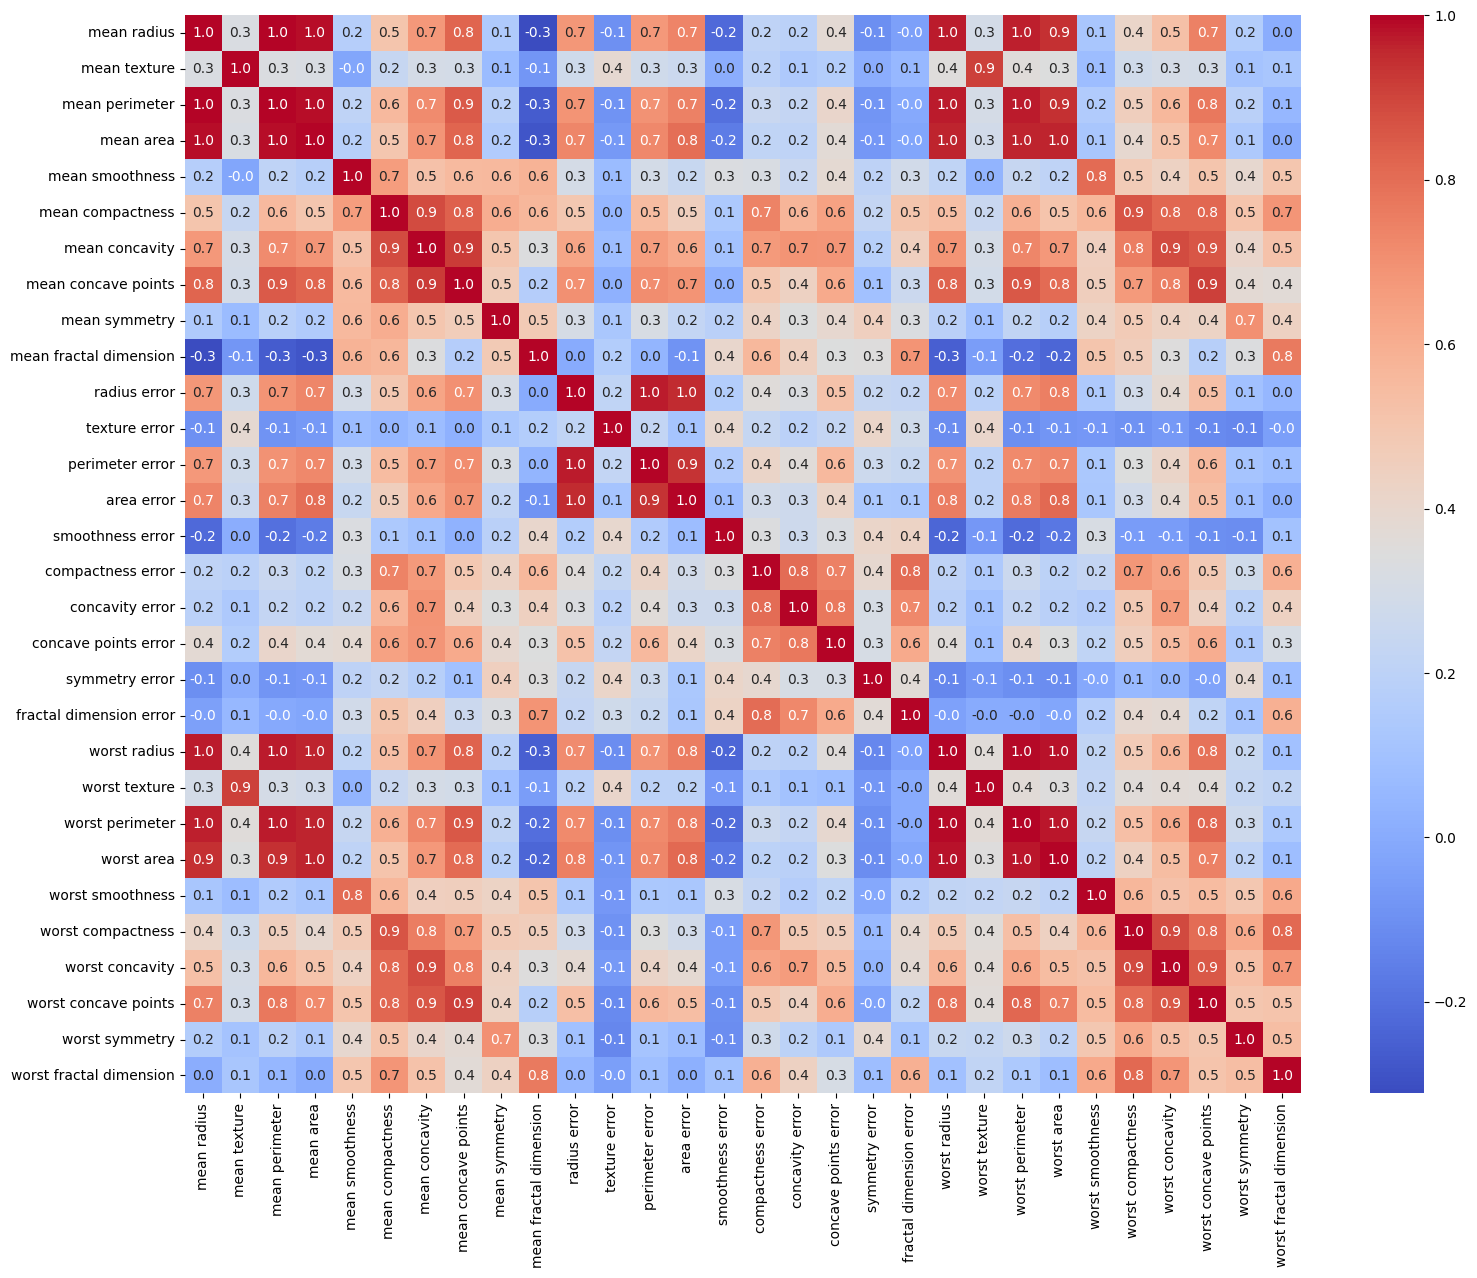

In [11]:
# ------------------------------------------
# Correlations
# ------------------------------------------

# Correlation heatmap between continuous features
plt.figure(figsize=(18, 14))
sns.heatmap(cancer_cont.corr(), annot=True, fmt=".1f", cmap='coolwarm')
plt.show()

In [12]:
# Identify feature pairs with correlations above a given threshold
corr = cancer_cont.corr().abs()     # absolute value to capture both positive and negative correlations
threshold = 0.7                     # multicollinearity threshold is consistent with commonly used guidelines (Dormann et al., 2013)

print("Correlations > 0.7:")

for i in range(len(corr.columns)):   # for each feature
    for j in range(i):               # for each feature before it, avoiding comparing a feature to itself or repeating pairs
        if corr.iloc[i, j] > threshold:
            print(f"{corr.columns[i]} - {corr.columns[j]}: {corr.iloc[i, j]:.2f}")

Correlations > 0.7:
mean perimeter - mean radius: 1.00
mean area - mean radius: 0.99
mean area - mean perimeter: 0.99
mean concavity - mean perimeter: 0.72
mean concavity - mean compactness: 0.88
mean concave points - mean radius: 0.82
mean concave points - mean perimeter: 0.85
mean concave points - mean area: 0.82
mean concave points - mean compactness: 0.83
mean concave points - mean concavity: 0.92
radius error - mean area: 0.73
perimeter error - mean area: 0.73
perimeter error - mean concave points: 0.71
perimeter error - radius error: 0.97
area error - mean radius: 0.74
area error - mean perimeter: 0.74
area error - mean area: 0.80
area error - radius error: 0.95
area error - perimeter error: 0.94
compactness error - mean compactness: 0.74
concavity error - compactness error: 0.80
concave points error - compactness error: 0.74
concave points error - concavity error: 0.77
fractal dimension error - compactness error: 0.80
fractal dimension error - concavity error: 0.73
worst radius 

The heatmap reveals quite a few strong correlations across the 30 continuous features. The subsequent list identifies all the feature pairs that have a correlation exceeding the commonly used threshold of |r| > 0.7 (Dormann et al., 2013).

It is evident that the strongest correlations are present among the size-related features as radius, perimeter, and area (across mean, SE, and worst) are almost perfectly correlated (r ≥ 0.99). This suggests that these variables represent the same core feature and are geometrically similar to each another. The concavity-related features (compactness, concavity, concave points) also form a highly intercorrelated group that have coefficients that exceed the threshold.

Retaining all 30 features would introduce severe multicollinearity to the model and it is therefore necessary to select representative features from each correlated cluster. According to the original paper, worst-value features represent the largest measurement across sampled nuclei and specifically capture extreme cellular abnormality. As only a few malignant cells may occur in a given sample, the extreme values will typically indicate a higher likelihood of malignancy compared to mean or SE (Street et al., 1993).

This reduces the feature set to the 10 worst-value features: worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, worst symmetry, and worst fractal dimension.

Within this reduced set, worst perimeter and worst area need to be excluded as well due to their strong correlation with worst radius. Both perimeter and area are mathematically derived from radius so it makes sense to use the most fundamental measurement as the size indicator.

worst concavity should also be excluded due to its high correlation with both worst concave points (r = 0.86) and worst compactness (r = 0.89).

Along with age, this brings down our initial set of features to 7.

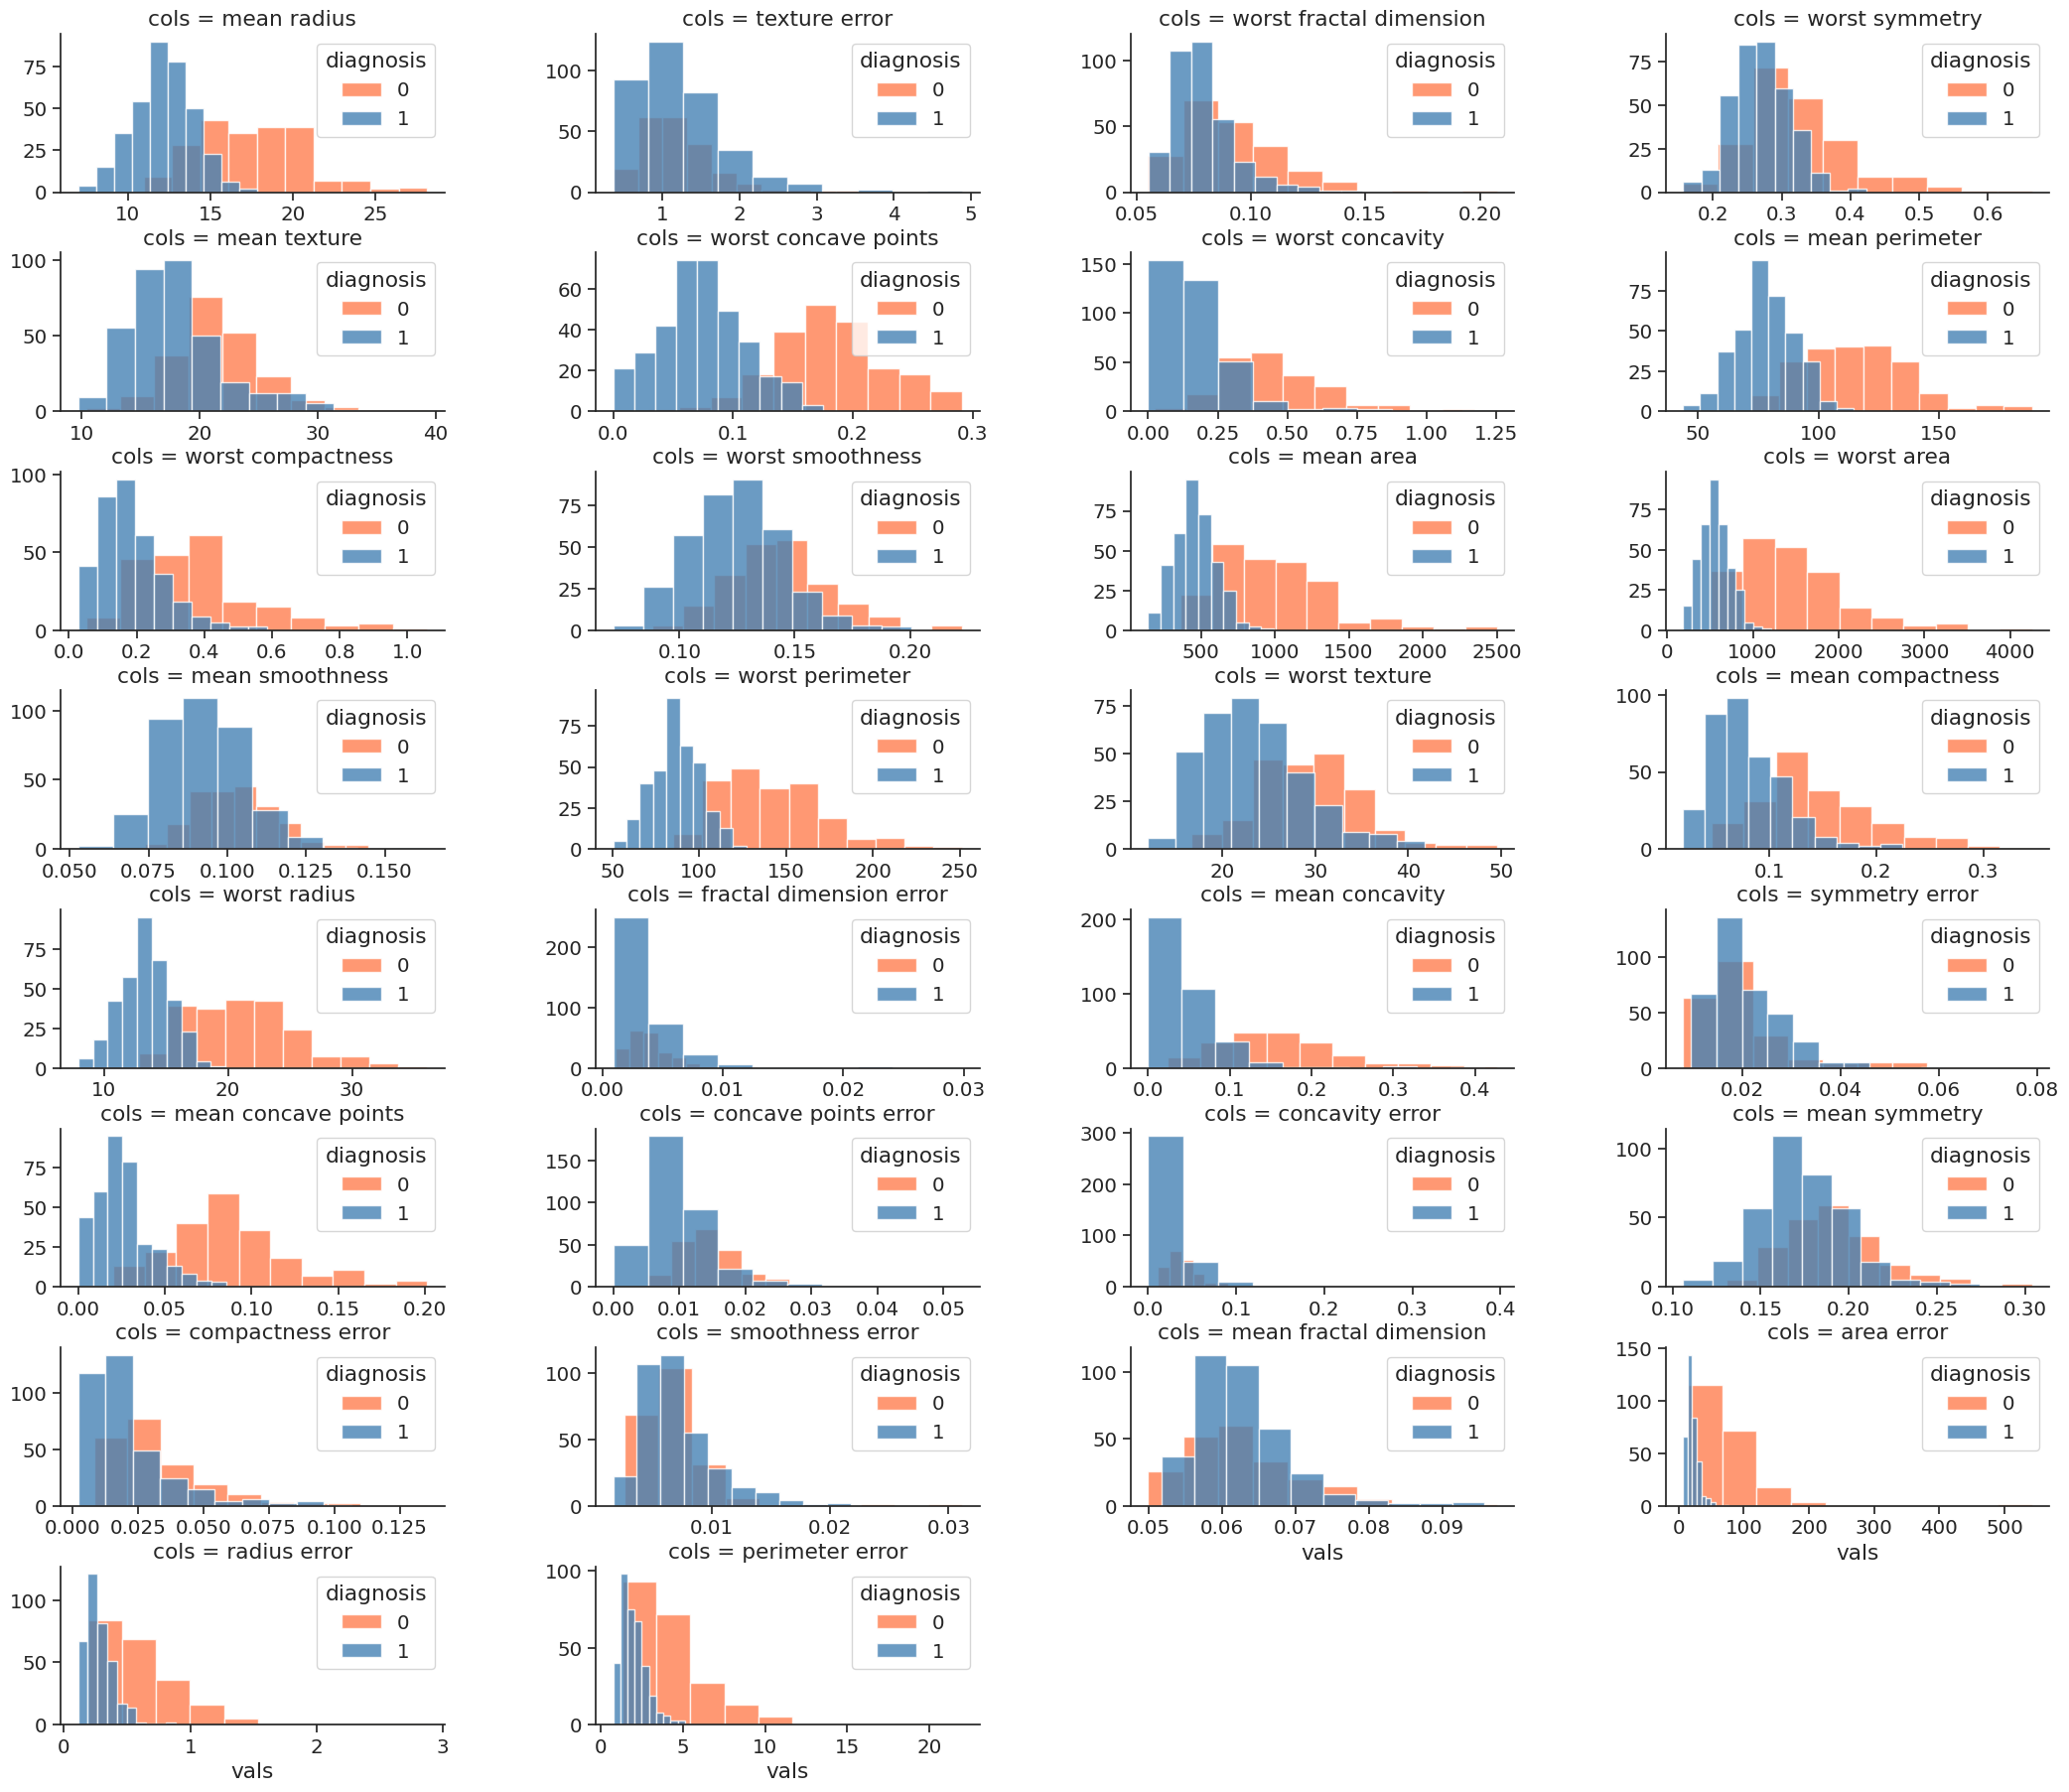

In [13]:
# ------------------------------------------
# Feature Distributions by Diagnosis
# ------------------------------------------

# Melt from wide to long format so each row is one feature-value observation
cancer_plot = cancer_clean.melt(['diagnosis'], var_name='cols', value_name='vals')
cancer_plot = cancer_plot.sort_values('diagnosis')

# Plot design
sns.set(style="ticks", font_scale=1.3)
pal = {0: 'coral', 1: 'steelblue'}   # 0 = malignant, 1 = benign

# Plot distribution of each continuous feature separated by diagnosis
p = sns.FacetGrid(cancer_plot, col='cols', hue='diagnosis', palette=pal, legend_out=False,
                  sharex=False, sharey=False, col_wrap=4)
p = p.map(plt.hist, "vals", alpha=0.8).add_legend()
p.fig.set_size_inches(22, 18)

for ax in p.axes.ravel():
    ax.legend(title="diagnosis")


This plot helps assess the distribution of benign and malignant classes across the 30 continuous features. Consistent with the literature, the worst-value size features (worst radius, worst perimeter, worst area) shows clear separation with malignant cases generally having higher values than the benign ones. This supports our decision to retain a worst-value 'size' feature in our final feature set. worst radius has been selected and the others have been excluded due to their redundancy.

Among the remaining 'worst-value' features, worst concave points, worst compactness, and worst texture also show strong separation with minimal overlap. worst smoothness and worst symmetry show moderate but potentially meaningful separation as well.

However, worst fractal dimension shows poor separation with considerable overlap between benign and malignant cases. It should therefore be excluded from the model.

Top 2 most correlated features: ['worst concave points', 'worst perimeter']


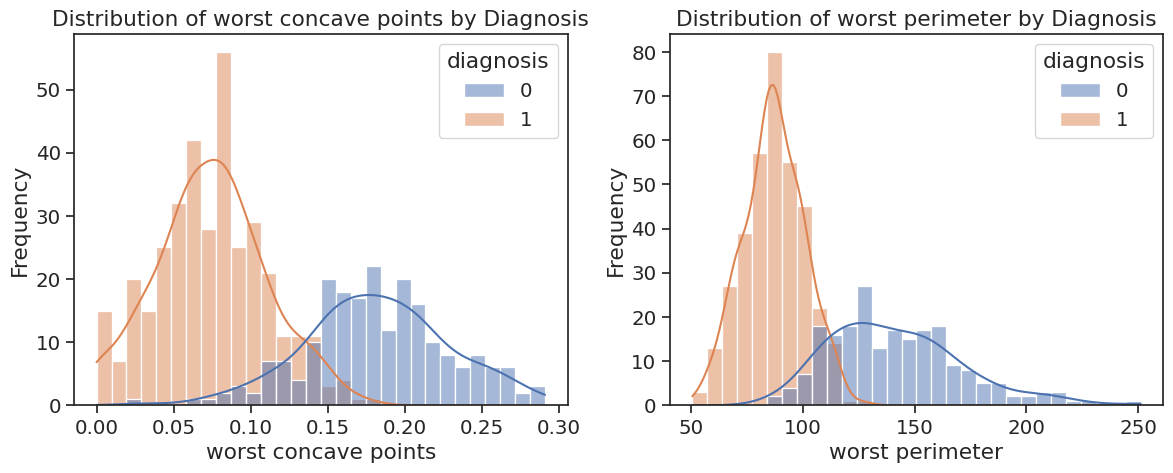

In [14]:
# Compute absolute correlations with diagnosis
correlation = (
    cancer_clean.corr(numeric_only=True)['diagnosis']
    .abs()
    .sort_values(ascending=False)
)

# Extract top 2 features
top_features = correlation.index[1:3]
print("Top 2 most correlated features:", top_features.tolist())

# Plot distribution of top 2 features by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feature in enumerate(top_features):
    sns.histplot(cancer_clean, x=feature, hue="diagnosis", bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature} by Diagnosis")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

Although worst concave points and worst perimeter show the highest correlation with diagnosis, worst perimeter is excluded due to high multicollinearity with the other size-related variables. worst concave points is preserved in the final list of features.

## 5. Baseline: regularised logistic regression


`Train_test_split` usually splits the data and target into training and test sets. However, the ANN also requires an additional validation set. It is also important that the same training data is used in the benchmark linear model and the ANN so that they are comparable, therefore, we cannot use different splitting techniques for each model. The most appropriate solution would involve splitting the data twice (Géron, 2022) -
-  Once to separate the test set and validation + training set from the full dataset
- And then again to separate the training set and validation set from the composite validation + training set that was prepared in the previous step.

This method ensures that the same training and test data is used by each model (with the ANN also using the validation set). The linear model doesn't require a validation set as it runs cross-validation directly using the training data.

0.1 is set as the 'test size' in both splits, ensuring that the test set is 10% of the full dataset and that validation set is 10% of the remaining sample (or ≈9% of the full dataset). This results in 460 samples in the training set, 52 samples in the validation set, and 57 samples in the test set.

In [15]:
# ------------------------------------------
# Splitting the data
# ------------------------------------------

# Step 1: Hold out 10% as the test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data[0], data[1],
    test_size=0.1,          # 10% held out for testing
    random_state=2026,      # random seed for reproducibility
    stratify=data[1]        # preserve class proportions in both sets
)

# Step 2: Split the remaining 90% into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.1,          # 10% of the 90% remaining ≈ 9% of total
    random_state=2026,
    stratify=y_train_val
)

# Check split sizes
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")


# Sources:
  # train_test_split — scikit-learn 1.8.0 documentation
  # Géron, 2022

Training set:   460 samples
Validation set: 52 samples
Test set:       57 samples


A `Pipeline` object is created to bundle the preprocessing and modelling steps into a single, reproducible workflow. By combining the scaler (`StandardScaler`) and the model (`LogisticRegression`) into one object, the pipeline prevents data leakage by ensuring that the same transformation is applied consistently during both training and cross-validation.

Scaling is necessary because logistic regression with regularization is sensitive to the scale of input features. Without it, features with larger ranges will disproportionately affect the regularization penalty and distort the coefficients. As part of the pipeline, `StandardScaler` is fitted only on the training folds during each cross-validation iteration, ensuring that the held-out scoring fold never influences the transformation applied to the training data.

The `saga` solver is used because it is the only sklearn solver that supports ElasticNet regularization, allowing the L1 ratio to blend between pure L1 and pure L2 penalties. As `l1_ratio: [0.0, 0.5, 1.0]` is a subsequently tuned hyperparameter, this flexibility is necessary. `max_iter=1000` is set higher than the default to ensure the solver has sufficient iterations to converge. Lastly, `random_state=2026` controls the saga solver's internal randomization to ensure reproducibility.

In [16]:
# ------------------------------------------
# Pipeline
# ------------------------------------------

# Prepare scaling and model in a single pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # standardize numerical features
    ('log_reg', LogisticRegression(solver='saga', max_iter=1000, random_state=2026))])


# Sources:
  # LogisticRegression - sklearn.linear_model API documentation

L1 ratio and C were selected as the two hyperparameters that will be tuned during grid search. Tuning `l1_ratio` alongside `C` allows the grid search to find the optimal regularization type and strength simultaneously.

- `C` controls regularization strength (lower the value, greater the regularization).

- `l1_ratio` controls the mix between L1 (lasso) and L2 (ridge) penalty. At 0.0 it's pure L2, at 1.0 it's pure L1, and at 0.5 it's a blend.

In [17]:
# ------------------------------------------
# Grid Search
# ------------------------------------------

# Hyperparameters set up in a grid
param_grid = {
    "log_reg__l1_ratio": [0.0, 0.5, 1.0],
    "log_reg__C": [0.01, 0.1, 1, 10, 100],
}

`GridSearchCV` is now prepared with the previously defined pipeline and parameter grid and fitted on the training data. For each of the 15 hyperparameter combinations, 3-fold cross-validation splits the training data into three equal folds - training the model on two folds and evaluating it on the third. This process is repeated three times so that every fold serves as the validation set once. The mean score across all three folds is then used to compare combinations, which reduces the risk of selecting hyperparameters that perform well only on a particular subset of the training data.

By default, sklearn's F1 score evaluates only the positive class (class 1, benign), which means that malignant performance would be ignored during hyperparameter selection. `f1_macro` is used instead as it averages the F1 score across both classes equally, ensuring that hyperparameter combinations are selected based on balanced performance across both malignant and benign predictions.

In [18]:
# Search all 15 hyperparameter combinations using 3-fold cross-validation
grid_search_log_reg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,               # 3-fold cross-validation
    scoring='f1_macro', # optimize for balanced performance across both classes
    n_jobs=-1,          # use all available CPU cores
    )


In [19]:
# Fit the grid search on training data
grid_search_log_reg.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'log_reg__C': [0.01, 0.1, ...], 'log_reg__l1_ratio': [0.0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

`C=10` and `l1_ratio=0.0` are the tuned hyperparameters identified by the grid search.

`C=10` indicates relatively weak regularization, suggesting that the model benefits from fitting the training data closely without needing to substantially shrink the coefficients.

`l1_ratio=0.0` corresponds to pure L2 (ridge) regularization, which implies that the model favours shrinking coefficients rather than eliminating them completely.

In [20]:
# Print best hyperparameter combination and corresponding score
print("Best Parameters:", grid_search_log_reg.best_params_)
print("Best Score:", grid_search_log_reg.best_score_)

Best Parameters: {'log_reg__C': 10, 'log_reg__l1_ratio': 0.0}
Best Score: 0.9695269377029202


The best cross-validated F1-macro score achieved with these hyperparameters is 0.97, indicating high and balanced performance across both malignant and benign classes.

## 6. Feedforward neural network


A random seed is set using `keras.utils.set_random_seed(2026)` to ensure reproducibility of the ANN training process. This Keras function sets three random seeds simultaneously and is equivalent to calling `random.seed(2026)`, `np.random.seed(2026)`, and `tf.random.set_seed(2026)` individually. Specifically, `random.seed` seeds Python's built-in random module, `np.random.seed` seeds NumPy's random number generator, and `tf.random.set_seed` controls TensorFlow's internal random operations including weight initialization. Setting all three provides the most comprehensive control over randomness in the training pipeline and improves its reproducibility.

For the ANN, input features are standardized using a `keras.layers.Normalization` layer (Géron, 2022). This is crucial because neural networks are sensitive to the magnitude of input features. Large differences in feature ranges can cause some weights to update much faster than others, resulting in slow or unstable convergence during gradient descent.

The normalization layer applies the transformation (input − mean) / √variance, which is mathematically equivalent to StandardScaler from scikit-learn (Géron, 2022). Rather than learning these statistics through gradient descent, the layer precomputes them from the training data via the `.adapt()` method. The `.adapt()` method is called only on the training data to prevent data leakage as fitting on the validation or test data would allow information about those sets to influence preprocessing and would invalidate the evaluation.


In [21]:
# Set random seed for reproducibility
keras.utils.set_random_seed(2026)

# Source: Python & NumPy utilities - Keras 3 API documentation

# ------------------------------------------
# Standardization
# ------------------------------------------

# Create normalization layer
norm_layer = keras.layers.Normalization()

# Compute the mean and standard deviation from X_train
norm_layer.adapt(X_train.values)  # fit on training data only to prevent data leakage

# Sources:
  # Géron, 2022
  # Normalization layer - Keras 3 API documentation

Next, the architecture of the Feedforward Neural Network is defined using Keras's Sequential API. Layers are stacked linearly and each layer receives the output of the previous one (Géron, 2022).

The model consists of an input layer, the previously defined normalization layer, three dense hidden layers with 10 nodes each, and an output layer:

- The Input layer specifies the shape of each sample passed to the model (in this case, 30 features).

- The Normalization layer standardizes input features using the mean and variance computed during `.adapt()`. Because it is part of the model architecture, standardization occurs automatically in the forward pass whenever `model.fit()` or `model.predict()` is called. This way, raw unscaled data can be passed directly without any external preprocessing steps.

- The three hidden layers and output layer are Dense layers, meaning every neuron in each layer is connected to every neuron in the previous layer. Each hidden layer contains 10 neurons. Furthermore, SELU (Scaled Exponential Linear Unit) activation is used for the hidden layers as it is self-normalizing. This means it automatically keeps activations in a stable range throughout the network (Klambauer et al., 2017). It requires the input to have approximately zero mean and unit variance, which is ensured by the previous normalization layer.

- sigmoid activation is used for the output layer as this is a binary classification task. The layer contains a single neuron because only one probability needs to be predicted, i.e., the probability of the sample belonging to the benign class (1). Sigmoid squashes this output to a value between 0 and 1, which can then be thresholded to produce a binary class prediction.


In [22]:
# ------------------------------------------
# Model Architecture
# ------------------------------------------

# Define the ANN model
model = models.Sequential([

    # Input layer
    layers.Input(shape=(X_train.shape[1],)),

    # Normalization layer
    norm_layer,

    # Hidden layers
    layers.Dense(10, activation='selu'),
    layers.Dense(10, activation='selu'),
    layers.Dense(10, activation='selu'),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

# Source: Géron, 2022

The model summary confirms that the architecture was set up correctly. The Input layer's shape (30 input features) is reflected in the output shape of the first visible layer (None, 30). None represents a variable batch size.

- `normalization`: stores 30 mean values and 30 variance values (one per feature) plus 1 count value used internally, giving 61 parameters. These are non-trainable parameters because they are fixed statistics precomputed from the training data via `.adapt()` rather than learned by gradient descent.

The subsequent layers have trainable parameters as their values are updated at each training step via backpropagation to minimize the loss.
- `dense` — first hidden layer: receives 30 inputs and outputs 10 activations (one per neuron). Each of the 10 neurons has 30 connection weights (one per input feature), plus 1 bias term, giving 310 parameters.
- `dense_1`/`dense_2` — second and third hidden layers: receive 10 inputs and output 10 activations. Each of the 10 neurons has 10 weights, plus 1 bias, giving 110 parameters each.
- `dense_3` — output layer: receives 10 inputs and outputs 1 activation (the predicted probability between 0 and 1). The single neuron has 10 weights plus 1 bias, giving 11 parameters.

In [23]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 30)             │            61 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602 (2.36 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 61 (248.00 B)

Compiling the model specifies how it will learn during training by defining the optimizer, loss function, and evaluation metric.

`adam` is a suitable optimizer for this task because it is computationally efficient, requires little memory, and typically requires little hyperparameter tuning (Kingma & Ba, 2015). It achieves faster convergence than standard stochastic gradient descent, making it well-suited for a dataset of this size and complexity.

`binary_crossentropy` is the appropriate loss function for binary classification as it measures the difference between the predicted probability output and the true binary label (0 or 1). It heavily penalizes wrong predictions that have high confidence, for example, a 0.95 probability for a malignant (0) label results in high loss.

Accuracy has been chosen as the primary metric for tracking performance and determining the best model. `metrics=['accuracy']` tells Keras to compute and record accuracy at the end of each epoch on both the training and validation sets so that it can be plotted and monitored. This does not influence how the model learns as learning is driven entirely by the `binary_crossentropy` loss function.

In [24]:
# ------------------------------------------
# Model Compilation
# ------------------------------------------

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Accuracy indicates percentage of correct predictions overall

# Source: Model training APIs - Keras 3 API documentation

During training, the model's performance may peak at an intermediate epoch and then plateau or slightly decline as it continues to fit the training data. Without a checkpoint, only the final epoch's weights are retained, which may not be the best-performing version of the model. The `ModelCheckpoint` callback addresses this by monitoring `val_accuracy` (accuracy computed on the validation set at the end of each epoch) and saving the model only when this metric improves, ensuring only the best-performing model on unseen validation data is retained (Géron, 2022).

By saving to Google Drive, the model can be reloaded for evaluation or prediction beyond the Colab session.

In [25]:
# ------------------------------------------
# Checkpoint Callback
# ------------------------------------------

# Mount Google Drive to access files
drive.mount('/content/drive')

# Path where the checkpoint will be saved
checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/Y2T1/HDAT9500/this notebook/check_model.keras'

Mounted at /content/drive


In [26]:
# Callback
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',       # Metric of interest to monitor
    save_best_only=True,          # Save only if validation accuracy improves
    save_weights_only=False,      # Save the full model, not just the weights
    mode='max',                   # Maximum val_accuracy is better
    verbose=1,                    # Print a message when the model is saved
)


# Sources:
  # ModelCheckpoint - Keras 3 API documentation

The model is finally trained on the training data for 15 epochs, with performance evaluated on the validation set at the end of each epoch.

Each epoch represents one full pass through the entire training dataset during which the model updates its weights via backpropagation to minimize the binary cross-entropy loss. The `ModelCheckpoint` callback runs after each epoch to determine whether the current model should be saved.

In [27]:
# ------------------------------------------
# Training the ANN model
# ------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=15,        # Number of training iterations over the dataset
    verbose=1,        # Display training progress
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_callback]
)

# Source: Model training APIs - Keras 3 API documentation

Epoch 1/15
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7784 - loss: 0.4998
Epoch 1: val_accuracy improved from None to 0.92308, saving model to /content/drive/MyDrive/Colab Notebooks/Y2T1/HDAT9500/this notebook/check_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Y2T1/HDAT9500/this notebook/check_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.8000 - loss: 0.4590 - val_accuracy: 0.9231 - val_loss: 0.3071
Epoch 2/15
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8958 - loss: 0.2814 
Epoch 2: val_accuracy did not improve from 0.92308
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9043 - loss: 0.2619 - val_accuracy: 0.9231 - val_loss: 0.2017
Epoch 3/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8750 - loss: 0.2512
Epoch 3: val_accuracy did not improve from 0.92308
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9348 - loss: 0.1809 - val_accuracy: 0.9231 - val_loss: 0.1547
Epoch 4/15
15/15 ━━━

Training history can be visualized to evaluate how loss and accuracy evolved over the 15 epochs. The loss plot shows how quickly the model's error decreases on both training and validation data while the accuracy plot shows the corresponding improvement in correct classifications. Comparing the training and validation curves helps identify whether the model is learning generalizable patterns or beginning to overfit to the training data.

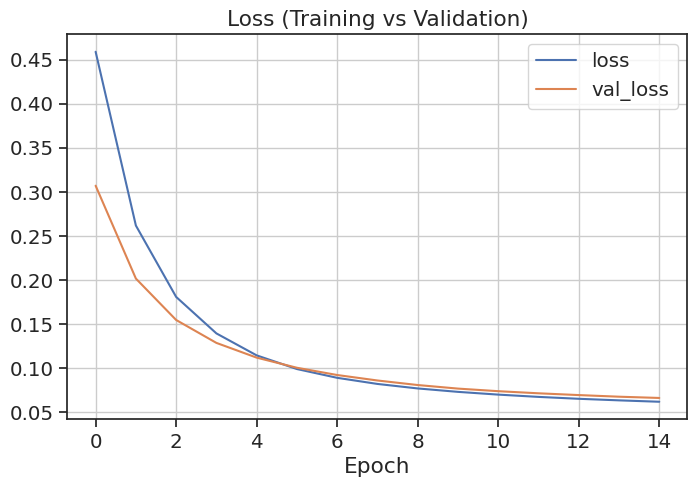

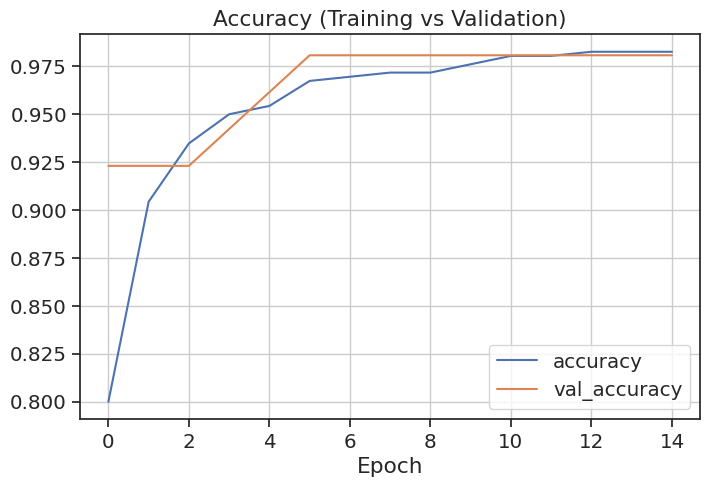

In [28]:
# Convert history to DataFrame
history_df = pd.DataFrame(history.history)

# Plot Loss
history_df[['loss', 'val_loss']].plot(
    figsize=(8, 5),
    title="Loss (Training vs Validation)",
    grid=True,
    xlabel="Epoch"
)
plt.show()

# Plot Accuracy
history_df[['accuracy', 'val_accuracy']].plot(
    figsize=(8, 5),
    title="Accuracy (Training vs Validation)",
    grid=True,
    xlabel="Epoch"
)
plt.show()

**Loss plot:**
Both training and validation loss decrease rapidly in the early epochs — training loss falling from 0.46 at epoch 1 to 0.10 by epoch 6 and validation loss drops from 0.31 to 0.10 over the same period. The curves converge and continue declining gradually through to epoch 15 (training loss 0.06, validation loss 0.07). There is no clear sign of divergence.

**Accuracy plot:**
Training accuracy rises steeply from 0.80 at epoch 1 to 0.97 by epoch 6 and then continues to improve gradually to 0.98 by epoch 15. Validation accuracy improves more sharply in the early epochs, reaching its peak of 0.98 at epoch 6 and remaining stable thereafter. The convergence of the two curves and the absence of any decline in validation accuracy confirm that the model seems to generalize well without overfitting.

`model` retains the weights from the final training epoch (epoch 15), so its evaluation results correspond to the validation metrics recorded at the end of training. On the other hand, `best_model` was saved automatically during training by the `ModelCheckpoint` callback whenever validation accuracy improved. Therefore, its validation accuracy should be equal to or higher than the validation accuracy of the final model. By comparing these two models, we can verify whether the checkpoint correctly saved the model with highest accuracy.

In [29]:
# Load the best saved model from the checkpoint file
best_model = load_model(checkpoint_path)

# Confirm that the model was loaded successfully
print(f"Best model loaded from: {checkpoint_path}")

# ---------------------------------------------------------
# Evaluate the final model
# ---------------------------------------------------------

results = model.evaluate(X_val, y_val, verbose=1) # 'model' refers to the model at the end of training

# Print evaluation results
print("\nFinal model evaluation on validation set:")
print(f"Final model - Validation Loss: {results[0]:.4f}")
print(f"Final model - Validation Accuracy: {results[1]:.4f}")

# ---------------------------------------------------------
# Evaluate the best saved model
# ---------------------------------------------------------

results_best_model = best_model.evaluate(X_val, y_val, verbose=1) # 'best_model' refers to the version saved by ModelCheckpoint

# Print evaluation results
print("\nBest saved model evaluation on validation set:")
print(f"Best model - Validation Loss: {results_best_model[0]:.4f}")
print(f"Best model - Validation Accuracy: {results_best_model[1]:.4f}")


Best model loaded from: /content/drive/MyDrive/Colab Notebooks/Y2T1/HDAT9500/this notebook/check_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9808 - loss: 0.0663

Final model evaluation on validation set:
Final model - Validation Loss: 0.0663
Final model - Validation Accuracy: 0.9808
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9808 - loss: 0.1006 

Best saved model evaluation on validation set:
Best model - Validation Loss: 0.1006
Best model - Validation Accuracy: 0.9808


The final model (weights from epoch 15) achieves a validation accuracy of 0.9808 and a validation loss of 0.0663. The best model was saved by the checkpoint at epoch 6, when `val_accuracy` first improved from 0.9615 to 0.9808, and achieves a validation loss of 0.1006.

Both models achieve identical validation accuracy, meaning the checkpoint did not provide a practical advantage in this run. This occurred because validation accuracy plateaued at epoch 6 and remained stable through to epoch 15. The final model has a lower validation loss as this metric appears to have continued to decrease after epoch 6 even though accuracy had plateaued. However, since accuracy was specified as the metric to track performance and determine the best-performing model, the checkpoint did not consider subsequent epochs as improvements and did not save them.

The checkpoint model (epoch 6) is retained for further evaluation as this workflow represents best practice for ANN training pipelines and is aligned with our decision to evaluate the best-performing model based on validation accuracy alone. Additionally, a lower validation loss does not necessarily mean better clinical utility. While it indicates the model is outputting more confident probabilities, probabilities that cluster near 0 or 1 may make it harder to identify genuinely uncertain cases that warrant additional clinical review. The epoch 6 checkpoint would produce probabilities that are less extreme on average due to its higher validation loss, but such conservative estimates for borderline cases may be a safer and more defensible choice when clinicians need to evaluate the diagnosis alongside the predicted probability.

## 7. Evaluation


### Logistic regression


The best model tuned during `GridSearchCV` is used to generate predictions on the training and test sets. For each set, a classification report is printed showing per-class precision, recall, and F1-score along with a confusion matrix. The confusion matrix rows represent true labels (Malignant = 0, Benign = 1) and columns represent predicted labels.

************* Evaluation on Training Set **************
*********** Classification Report *********************
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       172
           1       0.99      1.00      0.99       288

    accuracy                           0.99       460
   macro avg       0.99      0.99      0.99       460
weighted avg       0.99      0.99      0.99       460



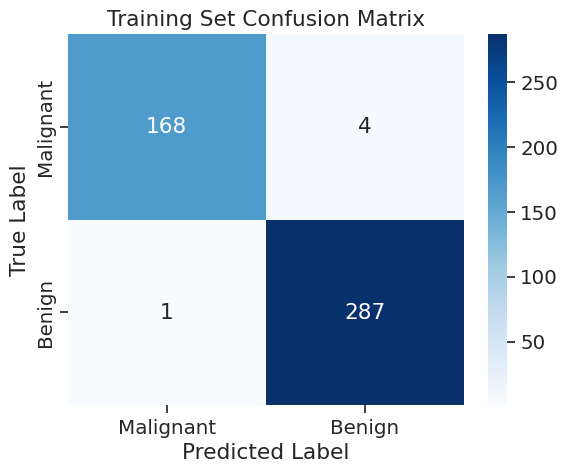

In [30]:
# ------------------------------------------
# Evaluation on Training Set
# ------------------------------------------

# Generate predictions on the training set
y_train_pred = grid_search_log_reg.predict(X_train)

print("************* Evaluation on Training Set **************")
print("*********** Classification Report *********************")
print(classification_report(y_train, y_train_pred))

# Compute confusion matrix
train_cm = confusion_matrix(y_train, y_train_pred, labels=[0, 1])
class_labels = ['Malignant', 'Benign']

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title("Training Set Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

The model achieved an accuracy of 0.99 on the training set (n=460), correctly classifying 168 of 172 malignant cases and 287 of 288 benign cases. There are 4 false negatives (malignant cases predicted as benign) and 1 false positive (benign case predicted as malignant). Thus, malignant precision is 0.99 and recall is 0.98, while benign precision and recall are 0.99 and 1.00 respectively. The F1-macro of 0.99 indicates near-perfect balanced performance across both classes.

************* Evaluation on Test Set **************
*********** Classification Report *********************
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        21
           1       0.97      0.97      0.97        36

    accuracy                           0.96        57
   macro avg       0.96      0.96      0.96        57
weighted avg       0.96      0.96      0.96        57



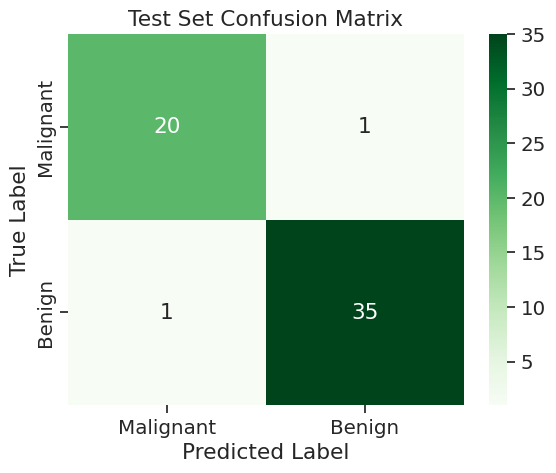

In [31]:
# ------------------------------------------
# Evaluation on Test Set
# ------------------------------------------

# Generate predictions on the test set
y_test_pred = grid_search_log_reg.predict(X_test)

print("************* Evaluation on Test Set **************")
print("*********** Classification Report *********************")
print(classification_report(y_test, y_test_pred))

# Compute confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
class_labels = ["Malignant", "Benign"]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title("Test Set Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

On the test set (n=57), the model achieved an accuracy of 0.96, correctly classifying 20 of 21 malignant cases and 35 of 36 benign cases. There is 1 false negative (a malignant tumour classified as benign) and 1 false positive (a benign tumour classified as malignant). Thus, malignant precision is 0.95 and recall is 0.95, while benign precision is 0.97 and recall is 0.97. The F1-macro of 0.96 is similar to training performance (0.99), suggesting that the model generalizes well to unseen data with no evidence of substantial overfitting.

The cross-validation results from `GridSearchCV` are also visualized as heatmaps to analyze how each hyperparameter influenced model performance across folds.

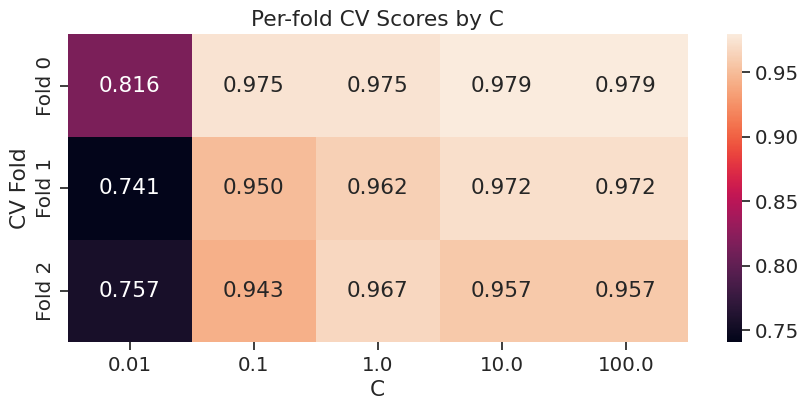

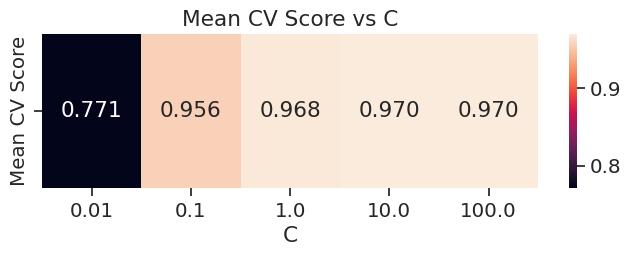

In [32]:
# ------------------------------------------
# Hyperparameter Analysis
# ------------------------------------------

# Store CV results in a DataFrame
results_df = pd.DataFrame(grid_search_log_reg.cv_results_)

# Group by C and compute mean CV score per fold across other hyperparameters
grouped_C = results_df.groupby('param_log_reg__C')[[
    'split0_test_score',
    'split1_test_score',
    'split2_test_score'
]].mean()

# Transpose so folds are rows
heatmap_C = grouped_C.T
heatmap_C.index = ['Fold 0', 'Fold 1', 'Fold 2']

# Plot per-fold CV scores by C
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_C, annot=True, fmt=".3f")
plt.title('Per-fold CV Scores by C')
plt.xlabel('C')
plt.ylabel('CV Fold')
plt.show()

# Compute mean CV score per C value averaged across all other hyperparameters
mean_by_C = results_df.groupby('param_log_reg__C')['mean_test_score'].mean()

# Reshape to 2D array
mean_scores_2d_C = mean_by_C.values[np.newaxis, :]

# Plot mean CV score by C
plt.figure(figsize=(8, 2))
sns.heatmap(mean_scores_2d_C, annot=True, fmt=".3f",
            xticklabels=mean_by_C.index, yticklabels=['Mean CV Score'])
plt.title('Mean CV Score vs C')
plt.xlabel('C')
plt.show()

`C=0.01` performs poorly across all folds (mean F1-macro approx. 0.771), indicating that excessive regularization prevents the model from adequately fitting the data. The performance improves considerably at higher C values, jumping to a mean F1-macro of 0.956 at `C=0.1` followed by 0.968 for `C=1.0` and 0.970 at `C=10`. No further gains were observed at `C=100`. This indicates that `C=10` provided a good balance between model fit and regularization.

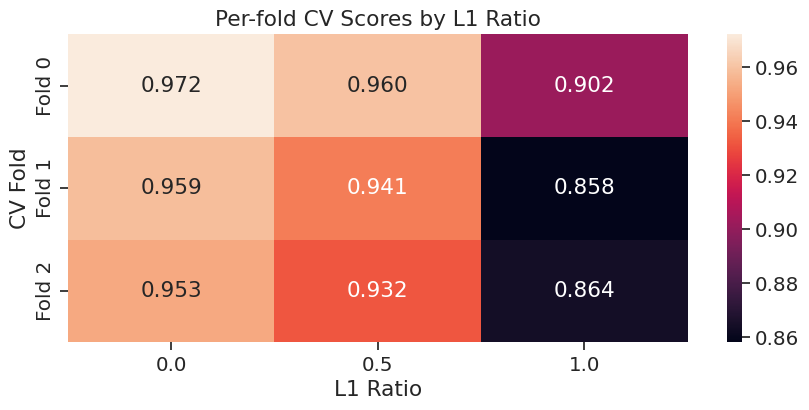

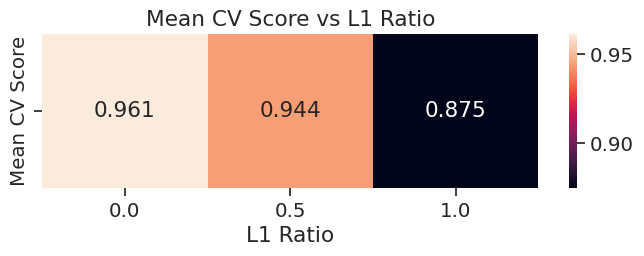

In [33]:
# Group by L1 ratio and compute mean CV score per fold across other hyperparameters
grouped_l1 = results_df.groupby('param_log_reg__l1_ratio')[[
    'split0_test_score',
    'split1_test_score',
    'split2_test_score'
]].mean()

# Transpose so folds are rows
heatmap_l1 = grouped_l1.T
heatmap_l1.index = ['Fold 0', 'Fold 1', 'Fold 2']

# Plot per-fold CV scores by L1 ratio
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_l1, annot=True, fmt=".3f")
plt.title('Per-fold CV Scores by L1 Ratio')
plt.xlabel('L1 Ratio')
plt.ylabel('CV Fold')
plt.show()

# Compute mean CV score per L1 ratio value averaged across all other hyperparameters
mean_by_l1 = results_df.groupby('param_log_reg__l1_ratio')['mean_test_score'].mean()

# Reshape to 2D array for heatmap rendering
mean_scores_2d_l1 = mean_by_l1.values[np.newaxis, :]

# Plot mean CV score by L1 ratio
plt.figure(figsize=(8, 2))
sns.heatmap(mean_scores_2d_l1, annot=True, fmt=".3f",
            xticklabels=mean_by_l1.index, yticklabels=['Mean CV Score'])
plt.title('Mean CV Score vs L1 Ratio')
plt.xlabel('L1 Ratio')
plt.show()

Pure L2 regularization (`l1_ratio=0.0`) consistently outperforms pure L1 (`l1_ratio=1.0`) across all folds (mean F1-macro 0.961 vs. 0.875). This suggests that shrinking coefficients rather than zeroing them out was more appropriate for this dataset.

### Neural network


The ANN model outputs probabilities due to the sigmoid activation. Hence, we need to convert the probabilities into class labels using a defined threshold.

This function generates model predictions for the entire dataset and returns the corresponding labels for each probability based on a theshold of 0.5. This is consistent with the default threshold used by scikit-learn's `.predict()` method for the logistic regression model, ensuring both models are evaluated under the same classification criteria.

The function is called for each dataset (training, validation, test) and uses the saved best-performing model to generate its predictions.

The model is now ready for evaluation against the true labels that were extracted from the target datasets (`y_train`, `y_val`, and `y_test`) using `.values`.

In [34]:
# ------------------------------------------
# Get Predictions
# ------------------------------------------

# Function to get binary predictions
def get_predictions(X, model):
    """Convert model probability outputs to binary class predictions using a 0.5 threshold."""
    probs = model.predict(X)                        # Get predictions directly from the dataset
    return (probs > 0.5).astype("int32").flatten()  # Returns 1 (benign) if probability > 0.5, else 0 (malignant)

# 'best_model' already loaded from checkpoint_path earlier in this session
# It can be reloaded from path_best_model directly for future use  -
  # best_model = load_model(path_best_model)

# Generate predictions for train, validation, and test sets
train_predictions = get_predictions(X_train, best_model)  # training set
val_predictions   = get_predictions(X_val,   best_model)  # validation set
test_predictions  = get_predictions(X_test,  best_model)  # test set

# Extract true labels for train, validation, and test sets
train_labels = y_train.values
val_labels   = y_val.values
test_labels  = y_test.values

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


This next function plots a confusion matrix using 3 parameters: the true labels, the predicted labels, and the plot title. It is called for each of the three datasets to visualize where the ANN's best model is making correct and incorrect predictions across training, validation, and test sets. This helps determine whether the model is generalizing well to unseen data.

In [35]:
# ------------------------------------------
# Confusion Matrices
# ------------------------------------------

# Function to plot a confusion matrix
def plot_confusion_matrix(labels, predictions, title):
    """Plot a labelled confusion matrix heatmap for binary classification results."""

    # Compute confusion matrix
    conf_matrix = confusion_matrix(labels, predictions)

    # Create the plot
    plt.figure(figsize=(6, 6))

    # Yellow-based colormap
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.YlOrBr)

    plt.title(title)
    plt.colorbar()

    # Define class labels
    class_names = ['Malignant', 'Benign']

    # Set tick marks
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Add numbers inside each cell
    for i, j in np.ndindex(conf_matrix.shape):
        plt.text(
            j, i,
            format(conf_matrix[i, j], 'd'),
            horizontalalignment="center",
            color="black"
        )

    # Axis labels
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # Improve layout
    plt.tight_layout()
    plt.show()

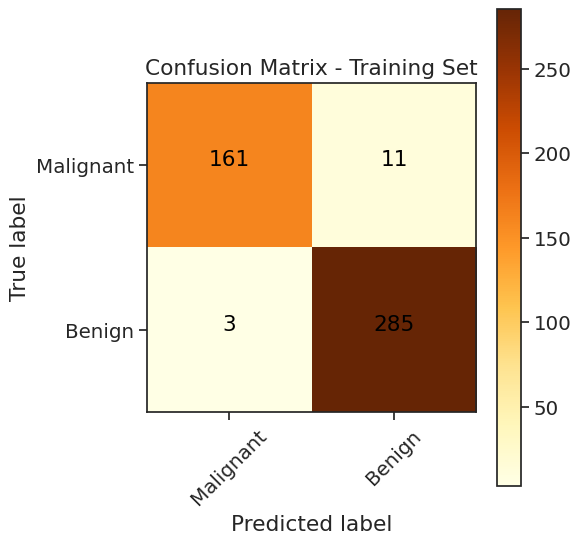

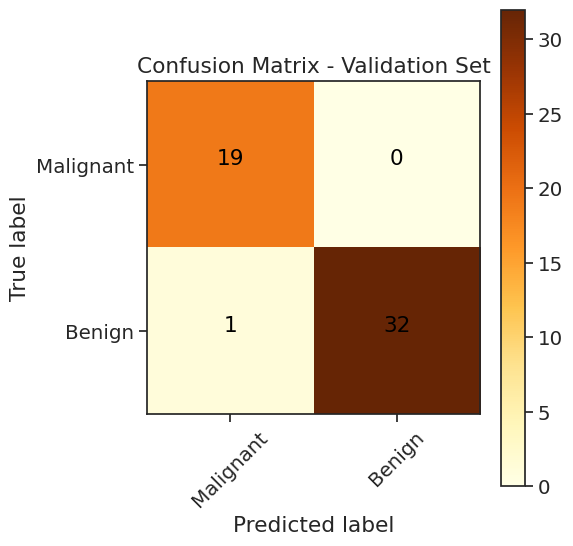

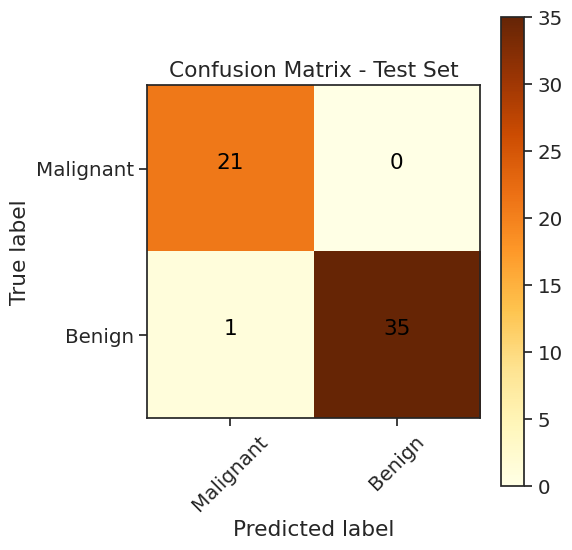

In [36]:
# Evaluation on Training Set
plot_confusion_matrix(
    train_labels,
    train_predictions,
    'Confusion Matrix - Training Set'
)

# Evaluation on Validation Set
plot_confusion_matrix(
    val_labels,
    val_predictions,
    'Confusion Matrix - Validation Set'
)

# Evaluation on Test Set
plot_confusion_matrix(
    test_labels,
    test_predictions,
    'Confusion Matrix - Test Set'
)

On the training set, 11 malignant cases are predicted as benign (false negatives) and 3 benign cases are predicted as malignant (false positives). On the validation set, all 19 malignant cases are correctly identified and there is only 1 false positive. Similarly, all 21 malignant cases are correctly identified on the test set and there is only 1 false positive present here as well.

Classification reports provide a detailed evaluation of model performance by showing precision, recall, and F1-score for each class. This is complementary to the confusion matrices as they provide numerical metrics for each class separately.

In [37]:
# ------------------------------------------
# Classification Reports
# ------------------------------------------

# Evaluation on Training Set
print('Classification Report - Training Set:')
print(classification_report(train_labels, train_predictions))

# Evaluation on Validation Set
print('\nClassification Report - Validation Set:')
print(classification_report(val_labels, val_predictions))

# Evaluation on Test Set
print('\nClassification Report - Test Set:')
print(classification_report(test_labels, test_predictions))

Classification Report - Training Set:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       172
           1       0.96      0.99      0.98       288

    accuracy                           0.97       460
   macro avg       0.97      0.96      0.97       460
weighted avg       0.97      0.97      0.97       460


Classification Report - Validation Set:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.97      0.98        33

    accuracy                           0.98        52
   macro avg       0.97      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52


Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.99        36

    accuracy                           0.98        57
   macro avg  

On the training set, the ANN achieves 0.97 accuracy and an F1-macro of 0.97. Precision and recall are high across both classes, though malignant recall is slightly lower at 0.94 compared to 0.99 for benign. Conversely, malignant precision is higher at 0.98 while benign precision is 0.96.

On the validation set, both accuracy and F1-macro improves to 0.98. Malignant recall reaches 1.00 with no false negatives, though malignant precision is 0.95 due to the 1 false positive. Benign recall is 0.97 and precision is perfect at 1.00. On the test set, accuracy and F1-macro are once again 0.98. Similar to the validation set, malignant recall reaches 1.00 with no false negatives and malignant precision is 0.95 due to the 1 false positive. Benign recall and precision are also consistent with the validation set (0.97 and 1.00 respectively).

Overall, performance is high and similar across all three sets, suggesting that the model generalizes well without overfitting.

## 8. Comparison and clinical safety


**Comparing the two models**

**Performance**

The logistic regression benchmark model performed strongly across both training and test sets (99% and 96% accuracy respectively). The ANN similarly showed consistent performance across all three splits, improving from 97% training accuracy to 98% on the validation and test sets. This indicates that both models generalize well to unseen data with no strong evidence of overfitting.

Examining our success criteria, malignant recall is 100% for the ANN and 95% logistic regression model, which suggests that both models are highly effective at detecting malignant cases. They both also achieve 95% malignant precision when classifying unseen data, which means they rarely misclassify benign patients as malignant.

That said, the difference in malignant recall between the two models is the result of a single misclassified patient on a test set of only 57 samples. It is therefore difficult to determine whether this gap reflects genuine model superiority or is simply due to the composition of this particular test split. Results should be interpreted cautiously and comparing these models solely on test performance should be avoided given the small sample size.

**Strengths and limitations in a healthcare context**

Both models output predicted probabilities alongside the binary class label, enabling clinicians to identify borderline cases and exercise their own judgement when the model has low confidence. However, logistic regression offers a deeper level of interpretability as its probabilities are derived from a transparent linear equation with known coefficients. Furthermore, these coefficients directly reflect the contribution of each feature to the predicted probability. This supports more informed clinical decision-making as the clinicians are able to understand which FNA measurements are driving the prediction and can then inspect them manually. Transparency is a significant advantage in healthcare and clinical stakeholders greatly value model decisions that are explainable and defensible. In general, logistic regression is well-suited for this task as it is computationally efficient and has established use in clinical prediction modelling.

However, this model also has a few limitations. As it assumes a linear decision boundary, it can only separate classes using a linear combination of input features. If the true relationship between FNA measurements and tumour classification is non-linear, logistic regression has the chance to systematically misclassify those cases regardless of how well it is tuned. It also assumes independence between features, however, many FNA measurements such as radius, perimeter, and area are geometrically correlated. The 3-fold cross-validation used during hyperparameter tuning is also lower than the standard 5 or 10-fold approach, resulting in less stable hyperparameter estimates. Furthermore, the model ended up misclassifying 1 malignant case on the test set. While this is a small count, it represents a clinically significant consequence. If similar patterns of misclassification are seen in a larger sample, the cummulative harm could be quite substantial. The logistic regression model was also trained on slightly less data than it could have been as `X_val` was withheld to ensure the test and training set matched the ANN. When the sample size is already small, training on even fewer samples reduces the model's ability to learn generalizable patterns from the data.

On the other hand, the ANN achieved a malignant recall of 1.00 on both the validation and test sets, successfully identifying every malignant case in unseen data. In the context of the research question, this is the most clinically valuable outcome as false negatives carry the greatest harm to patients and suggests that the model is meeting the primary success criterion. Beyond performance, the ANN's ability to learn non-linear relationships between features makes it theoretically more flexible. The relationship between cellular morphology and malignancy is likely to be driven by complex biological processes that result in non-linear interactions between features. Unlike logistic regression that assumes the target classes can be separated by a linear boundary, the ANN can capture the complex patterns automatically without making any assumptions. This also means that the model is more scalable as the ANN can continue to learn increasingly complex patterns with more training data whereas logistic regression's performance is bounded by its linear assumption regardless of how much data is available.

However, the ANN carries notable limitations as well. It is considerably less interpretable than logistic regression as its predictions come from a series of non-linear transformations across multiple layers. This makes it difficult to extract and explain the contribution of individual features to clinicians, patients, or other stakeholders. Additionally, the model's performance is contingent on the specific random seed used for weight initialization. While results are reproducible with the same seed, different seeds produce different weight initializations. This means that the reported results reflect one particular training trajectory rather than a stable outcome. This hinders reproducibility and would be concerning from a clinical governance perspective as the performance is not independent of the seed choice. Furthermore, since validation accuracy was used as the checkpoint criterion rather than class-specific metrics such as malignant recall, the saved model is not guaranteed to be the epoch with the best performance on the primary success criterion. Finally, the small validation set makes any validation metric an unreliable criterion for model selection. A single misclassification shifts validation accuracy by nearly 2%, which means the saved checkpoint's performance may be due to the composition of the validation set rather than a genuine performance peak.

Both models share several limitations too. They were trained only on 460 samples from a single source and so the results observed may not translate to a broader or more demographically diverse clinical population. This concern is more acute for the ANN as neural networks typically require substantially more data to learn stable and generalizable representations. The demographic composition of the original Wisconsin dataset is also not reported, which means that performance on underrepresented subgroups such as younger patients, different ethnicities, or cases with poorer FNA sampling quality cannot be guaranteed either. Lastly, both models provide no information on cancer stage, severity, or subtype of the malignancy. This limits their clinical utility for real-world deployment as clinicians would typically prefer more detailed information to help them assess the cancer growth.



**Which model to deploy**

Despite the ANN's superior malignant recall on this dataset, the logistic regression model is preferable for deployment.

In a healthcare setting, a model that clinicians cannot understand or evaluate is difficult to trust, adopt, and regulate. Logistic regression's interpretable coefficients allow clinicians to see which features are driving a prediction and can inform their evaluation. This can also help them communicate the basis of that diagnosis to patients in plain terms. For example, explaining that tumour radius and texture measurements were the primary factors influencing the result can increase a patient's trust in their diagnosis and may even be a legal and ethical requirement in a clinical practice. This transparency is particularly important given that the FNA-based model classification is intended as a preliminary screening tool or decision-aid and not a definitive diagnostic instrument. Alternatively, the ANN poses a significant challenge for clinical adoption as trust and accountability are essential considerations before any new tool is implemented. Moreover, clinical models like these may be subject to additional administrative oversight. In Australia, the TGA regulates software as a medical device and may require detailed documentation of how the software works and its limitations.  Additionally, the EU AI Act classifies high-risk AI systems in healthcare and requires transparency in how predictions are made. Logistic regression is more likely to satisfy these requirements by design, whereas the ANN's black-box nature would require significant evaluation before regulatory approval can be obtained.

From a healthcare system and infrastructure perspective, logistic regression is also considerably simpler and cheaper to deploy and maintain. It has no GPU dependency and requires no strict version control to ensure the deployed model matches the validated checkpoint. The ANN, in contrast, needs to ensure the saved model weights are preserved and deployed exactly as validated, which adds operational complexity that may not be feasible in clinical settings where technical expertise is limited. Furthermore, while the ANN achieves perfect malignant recall on this test set, the performance gap is due to a single case on a test set of only 57 samples. It cannot be concluded with confidence that this superior performance would hold across a larger or more demographically diverse population. Hence, committing to a less interpretable and operationally complex model on this basis would be difficult to justify to clinical governance stakeholders, especially if the performance difference remains marginal even after training on more data.

That said, the logistic regression model's one missed malignant case highlights a real clinical risk. It might be acceptable for clinicians to use it as a supplementary decision-aid alongside their own examination, however, it cannot be used as an independent preliminary screening tool until it achieves perfect malignant recall on larger, more diverse datasets. This would be necessary prior to any real-world deployment.

**Communicating uncertainty and confidence**

Stakeholders including clinicians, patients, IT staff, and compliance teams have varying levels of technical literacy. Hence, effective communication of model uncertainty must be tailored to their individual needs and use of the model.

For clinicians, the most useful form of uncertainty to communicate is the predicted probability output along with the binary class label. A prediction of 0.51 (barely above the threshold) should be flagged as a low-confidence case and treated differently from a prediction of 0.97. Cases falling within a defined uncertainty interval (for example, predicted probabilities between 0.30 and 0.70) could be automatically escalated for additional clinical review or a follow-up biopsy. This is particularly relevant for the logistic regression model as clinicians can not only see the confidence of a prediction but also the feature coefficients that influenced the classification. Evaluating this information can directly influence their decision-making and inform what to communicate to their patients.

For patients, uncertainty should be communicated in plain language without statistical jargon. Patients should be informed that the model is a decision support tool that assists clinical judgment rather than a definitive diagnostic system. They should also be told that results carry a degree of uncertainty and that additional tests may be recommended if their results are borderline. Framing uncertainty as a reason for additional care rather than a failure of the technology can help maintain patients' trust in the diagnostic process.

For IT staff, communication should focus on quantified model performance metrics such as accuracy, false negative rates, and confidence score distributions tracked over time. As data distributions shift and the model is trained on data from new patient populations, its confidence and accuracy may decline before it is immediately obvious. IT staff need to establish clear thresholds for when performance has dropped to an unacceptable level as well as be given detailed protocols on when the model requires revalidation or retraining. Version control is also essential to ensure that the uncertainty characteristics of the deployed model match those of the validated one. Their role is to maintain the model's integrity and flag any technical issues to clinical and governance teams promptly.

For healthcare governance and compliance teams, communication should focus on documented evidence of model safety including classification reports, confusion matrices, known error rates, and performance across patient subgroups. The recall rate for the malignant class represents the most clinically consequential error and it would be of particular interest to this group to assess how that metric holds for different patient populations within their jurisdiction. Clear documentation of the model's uncertainty and failure rates helps governance teams assess whether the model is meeting acceptable safety thresholds and satisfies regulatory requirements before and during deployment. Model confidence should also be reported at the population level (for example, the proportion of predictions that have low-confidence) to help governance teams understand how often the model is uncertain and whether additional clinical safeguards are needed in those cases.

**Design improvements and risk mitigation**

Several design changes and safeguards could improve the safety and trustworthiness of this model in clinical practice.

**Classification threshold adjustment.** The default threshold of 0.5 for converting predicted probabilities to class labels is not clinically optimized. In a cancer screening context, the unequal consequences of errors justify raising the threshold above 0.5 as a missed diagnosis for a malignant patient is far more harmful than an unnecessary follow-up for a benign patient. For example, a threshold of 0.6 or 0.7 would require greater confidence in a benign prediction before classifying a case as benign, thereby increasing recall for the malignant class at the cost of a modest increase in false positives. In practice, the optimal threshold could be determined empirically using a precision-recall curve or ROC-AUC analysis on a held-out validation set, which can evaluate model performance across all possible thresholds rather than at the fixed default of 0.5. This should also be reviewed with clinical stakeholders to agree on an acceptable tradeoff.

**Checkpoint metric selection.** Here, ModelCheckpoint was configured to monitor `val_accuracy`. However, in a clinical context where malignant recall is the primary success criterion, monitoring recall for the malignant class specifically would be more appropriate. This would ensure that the saved model is the one that minimizes false negatives rather than the one with the highest overall accuracy. Optimizing directly for the clinically relevant metric would better align the model selection process with its primary clinical objective.

**Larger and more representative training data.** Both models were trained on a relatively small dataset of 569 samples from a single institution. Before clinical deployment, the models should be retrained and validated on substantially larger, multi-site datasets encompassing greater demographic and clinical diversity. This is necessary to assess whether the observed performance generalizes beyond the original study population.

**Human-in-the-loop design.** The model should be deployed as a clinical decision support tool rather than an autonomous diagnostic system. All predictions should be reviewed by a qualified clinician before any clinical action is taken, particularly for borderline or low-confidence cases. The model output should be presented alongside the raw predicted probability and a clear statement of the model's known limitations and error rates. If sufficient evidence continues to confirm a perfect malignant recall, then there is potential for it to be used as a preliminary screening tool for triage to filter benign cases from the ones requring clinician assessment. Prior to deployment, structured training should also be provided to clinicians on how to interpret model outputs, predicted probabilities, and the model's known limitations, ensuring it is used appropriately as a support tool rather than a substitute for clinical judgment.

**Probability calibration.** Before deployment, the model's predicted probabilities should be calibrated against observed outcomes to ensure they accurately reflect the true likelihood of malignancy. A well-calibrated model predicting a probability of 0.8 should correspond to approximately 80% of such cases being truly malignant. Without calibration, the predicted probabilities used to flag borderline cases for additional review may actually be misleading.

**Model monitoring and drift detection.** Once deployed, the model's performance should be monitored continuously against incoming data to detect changes in patient population, imaging quality, or measurement practices that may cause the model's real-world performance to diverge from its validated performance. The model should be periodically retrained and revalidated as required.

**Audit trails and governance.** All model predictions should be logged alongside patient identifiers, predicted probabilities, and the final clinical decision to support its auditing and accountability. Clear documentation of the model's training data, performance characteristics, known failures, and intended use cases should be maintained and accessible to the health agencies and clinical teams using the model. Performance should also be reported across relevant patient subgroups including age, ethnicity, and other key demographics to identify any disparities in model performance for those specific patient populations. Informed consent should definitely be obtained from patients acknowledging that a model is contributing to their diagnostic process.

**ANN architecture optimization.** The ANN architecture used Here was fixed rather than selected through a systematic search. In a real deployment context, the architecture hyperparameters should be specifically tuned. `keras_tuner` could be used to tune hyperparameters including the number of layers, number of neurons per layer, and activation functions to be searched over in a systematic way. However, this can be computationally expensive as each architecture combination requires a full training run. For a dataset of this size, the gains from hyperparameter tuning are likely minimal. More training data from representative patient populations would probably yield greater improvements than simply tuning the model structure itself.

**Early stopping.** Rather than training for a fixed number of epochs, early stopping automatically halts training when the validation metric stops improving. This prevents unnecessary computation and reduces the risk of overfitting. This can be combined with an epoch limit much higher than 15, allowing the model to train for as long as it is genuinely improving. In Keras, this can be implemented via the EarlyStopping callback alongside the ModelCheckpoint and can be a straightforward and low-cost improvement to the current training pipeline.

## References

Géron, A (2022). 10. Introduction to Artificial Neural Networks with Keras. In *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition*. O'Reilly Media, Inc.

Kingma, D.P. & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations (ICLR).* https://arxiv.org/abs/1412.6980.

Klambauer, G., Unterthiner, T., Mayr, A. & Hochreiter, S. (2017). *Self-normalizing neural networks. Advances in Neural Information Processing Systems*, 30. https://arxiv.org/abs/1706.02515.

National Cancer Institute. (n.d.). What is cancer? Retrieved March 26, 2026, from https://www.cancer.gov/about-cancer/understanding/what-is-cancer

Street, W.N., Wolberg, W.H. & Mangasarian, O.L. (1993). Nuclear feature extraction for breast tumor diagnosis. *IS&T/SPIE International Symposium on Electronic Imaging: Science and Technology*, Vol. 1905, pp. 861–870.


**API documentation:**

Keras 3
- keras.io. (n.d.). *keras.utils.set_random_seed*. Retrieved from https://keras.io/api/utils/python_utils/#set_random_seed-function
- keras.io. (n.d.). *Model training APIs*. Retrieved from https://keras.io/api/models/model_training_apis/
- keras.io. (n.d.). *ModelCheckpoint*. Retrieved from https://keras.io/api/callbacks/model_checkpoint/
- keras.io. (n.d.). *Normalization layer.* Retrieved from https://keras.io/api/layers/preprocessing_layers/numerical/normalization/

Scikit-learn
- scikit-learn. (n.d.). *load_breast_cancer*. Retrieved from https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html.
- scikit-learn. (n.d.). *LogisticRegression*. Retrieved from https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- scikit-learn. (n.d.). *sklearn.metrics*. Retrieved from https://scikit-learn.org/stable/api/sklearn.metrics.html
